## Aim 

In this code, the Land Surface Temperature data (LST) using the calculation of Ermeida et al. (2020) at the ward level are merged with the indices such as NDVI, NDBI, NNDWI and BSI. The script with the computation of the LST can be found [here](https://github.com/EllenB/lstroad/blob/main/scripts/04_lst_bangalore_ermida.js) and the script for the indices [here](https://github.com/EllenB/lstroad/blob/main/notebooks/04_indices_bangalore.ipynb). 

In [41]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [42]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [43]:
lst_path = PROCESSED_DIR /'lstermidasummer_bang.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstermidasummer_bang.csv


In [44]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [45]:
df_lst_mean_summer.head()

,system:index,Corporatio,mean,ward_id,ward_name,.geo
0,00000000000000000007,Central,37.101195,24,24 - Agaram,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
1,00000000000000000009,Central,38.345464,11,11 - Old Baiyappanahalli,"{""type"":""Polygon"",""coordinates"":[[[77.63789444..."
2,00000000000000000015,Central,38.115046,41,41 - V.V Puram,"{""type"":""Polygon"",""coordinates"":[[[77.57363440..."
3,0000000000000000001a,Central,39.383769,51,51 - Old Guddadahalli,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
4,0000000000000000002e,Central,37.982895,13,13 - Krishnaiahnapalya,"{""type"":""Polygon"",""coordinates"":[[[77.64552398..."


In [46]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 35.15153817773115.
The maximum temperature is 41.64818002114797.


### Indices

In [47]:
indices_path = PROCESSED_DIR /'indices_wards_geemap_bang.csv'
df_indices = pd.read_csv(indices_path)

In [48]:
df_indices.head()

,system:index,Corporatio,ward_name,MNDWI,NDBI,BSI,NDVI,ward_id
0,0,West,25 - Vinayaka Layout,-0.337424,-0.022776,0.071129,0.297025,25
1,1,North,2 - Aerocity,-0.337253,-0.029647,0.068905,0.305434,2
2,2,North,3 - Chowdeshwari ward,-0.399920,-0.034285,0.058472,0.368122,3
3,3,East,15 - Ramamurthy Nagara,-0.274119,-0.026672,0.073142,0.249989,15
4,4,North,58 - Nagashettyhalli,-0.323029,-0.038849,0.057884,0.299915,58


In [49]:
merged = pd.merge(df_lst_mean_summer, df_indices, on='ward_name')
merged.head()

,system:index_x,Corporatio_x,mean,ward_id_x,ward_name,.geo,system:index_y,Corporatio_y,MNDWI,NDBI,BSI,NDVI,ward_id_y
0,00000000000000000007,Central,37.101195,24,24 - Agaram,"{""type"":""GeometryCollection"",""geometries"":[{""t...",7,Central,-0.429728,-0.074642,0.001659,0.461882,24
1,00000000000000000009,Central,38.345464,11,11 - Old Baiyappanahalli,"{""type"":""Polygon"",""coordinates"":[[[77.63789444...",9,Central,-0.371504,-0.025391,0.056868,0.342378,11
2,00000000000000000015,Central,38.115046,41,41 - V.V Puram,"{""type"":""Polygon"",""coordinates"":[[[77.57363440...",21,Central,-0.306449,-0.023526,0.056554,0.275300,41
3,0000000000000000001a,Central,39.383769,51,51 - Old Guddadahalli,"{""type"":""GeometryCollection"",""geometries"":[{""t...",26,Central,-0.292448,0.075088,0.129800,0.167152,51
4,0000000000000000002e,Central,37.982895,13,13 - Krishnaiahnapalya,"{""type"":""Polygon"",""coordinates"":[[[77.64552398...",46,Central,-0.321232,-0.012467,0.077710,0.274986,13


Only retain the relevant variables and rename:

In [50]:
merged = merged[['ward_name', 'mean', 'ward_id_x', 'Corporatio_x', 'MNDWI', 'NDBI', 'BSI', 'NDVI']]
merged.head()

,ward_name,mean,ward_id_x,Corporatio_x,MNDWI,NDBI,BSI,NDVI
0,24 - Agaram,37.101195,24,Central,-0.429728,-0.074642,0.001659,0.461882
1,11 - Old Baiyappanahalli,38.345464,11,Central,-0.371504,-0.025391,0.056868,0.342378
2,41 - V.V Puram,38.115046,41,Central,-0.306449,-0.023526,0.056554,0.275300
3,51 - Old Guddadahalli,39.383769,51,Central,-0.292448,0.075088,0.129800,0.167152
4,13 - Krishnaiahnapalya,37.982895,13,Central,-0.321232,-0.012467,0.077710,0.274986


In [51]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporation',
    'mean': 'mean_lst'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,MNDWI,NDBI,BSI,NDVI
0,24 - Agaram,37.101195,24,Central,-0.429728,-0.074642,0.001659,0.461882
1,11 - Old Baiyappanahalli,38.345464,11,Central,-0.371504,-0.025391,0.056868,0.342378
2,41 - V.V Puram,38.115046,41,Central,-0.306449,-0.023526,0.056554,0.275300
3,51 - Old Guddadahalli,39.383769,51,Central,-0.292448,0.075088,0.129800,0.167152
4,13 - Krishnaiahnapalya,37.982895,13,Central,-0.321232,-0.012467,0.077710,0.274986


## Correlations

In [52]:
vars_df = merged[[
    "mean_lst",
    "NDVI",
    "NDBI",
    "BSI",
    "MNDWI"
]].dropna()

In [53]:
corr = vars_df.corr(method="pearson")

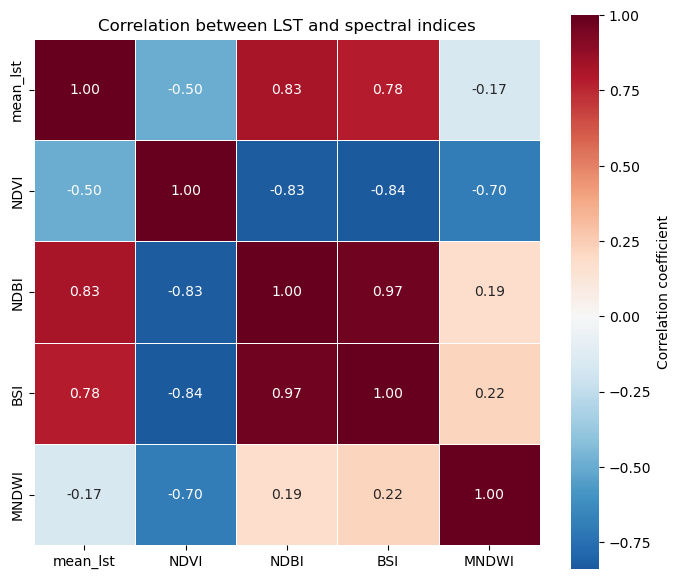

In [54]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore_ermida.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()


#### NDVI

In [55]:
# x and y
x = merged[["NDVI"]]
Y = merged["mean_lst"]

In [56]:
fig_path = IMAGES_DIR / 'regression_bangalore_NDVI_ermida.png'

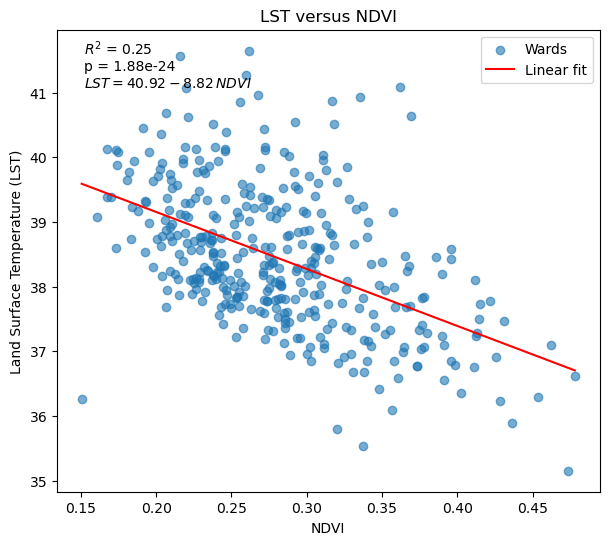

In [57]:
# x and y
x = merged["NDVI"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDVI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDVI")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,NDVI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [58]:
p_value

np.float64(1.8783942152269764e-24)

In [59]:
print(slope, intercept, r_value)

-8.820277952737863 40.91848130027973 -0.49734468591844955


In [60]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.49734468591844977), pvalue=np.float64(1.8783942152268464e-24))

In [61]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDVI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     120.6
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.88e-24
Time:                        22:26:22   Log-Likelihood:                -504.98
No. Observations:                 369   AIC:                             1014.
Df Residuals:                     367   BIC:                             1022.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.9185      0.230    177.789      0.0

In [62]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.49734468591844977), pvalue=np.float64(1.8783942152268464e-24))

#### MNDWI

In [63]:
# x and y
x = merged["MNDWI"]
y = merged["mean_lst"]

In [64]:
fig_path = IMAGES_DIR / 'regression_bangalore_MNDWI_ermida.png'

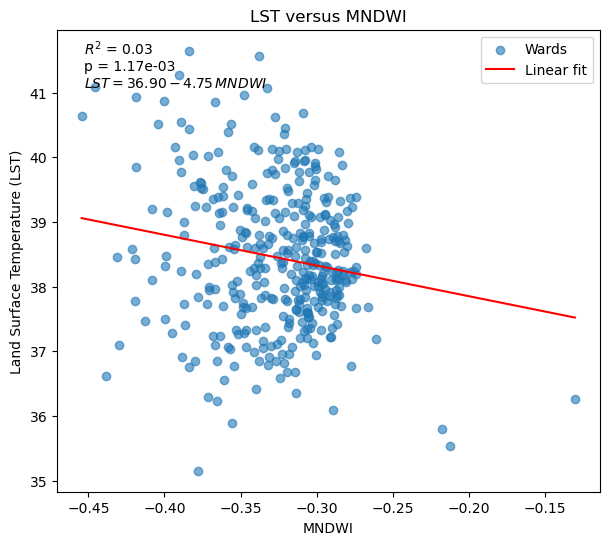

In [65]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("MNDWI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus MNDWI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,MNDWI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [66]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['MNDWI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     10.70
Date:                Wed, 14 Jan 2026   Prob (F-statistic):            0.00117
Time:                        22:26:27   Log-Likelihood:                -552.11
No. Observations:                 369   AIC:                             1108.
Df Residuals:                     367   BIC:                             1116.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.9004      0.477     77.333      0.0

In [67]:
pearsonr(merged['MNDWI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.16832334791541764), pvalue=np.float64(0.0011720215805029158))

#### NDBI

In [68]:
# x and y
x = merged["NDBI"]
y = merged["mean_lst"]

In [69]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [70]:
fig_path = IMAGES_DIR / 'regression_bangalore_NDBI_ermida.png'

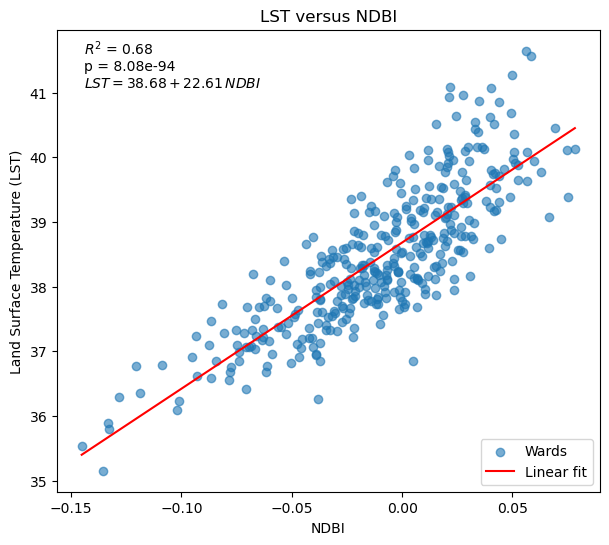

In [71]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDBI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,NDBI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [72]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDBI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     794.2
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           8.08e-94
Time:                        22:26:32   Log-Likelihood:                -344.90
No. Observations:                 369   AIC:                             693.8
Df Residuals:                     367   BIC:                             701.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.6814      0.033   1165.397      0.0

In [73]:
pearsonr(merged['NDBI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.8270106635583814), pvalue=np.float64(8.077817481812875e-94))

#### BSI

In [74]:
# x and y
x = merged["BSI"]
y = merged["mean_lst"]

In [75]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [76]:
fig_path = IMAGES_DIR / 'regression_bangalore_BSI_ermida.png'

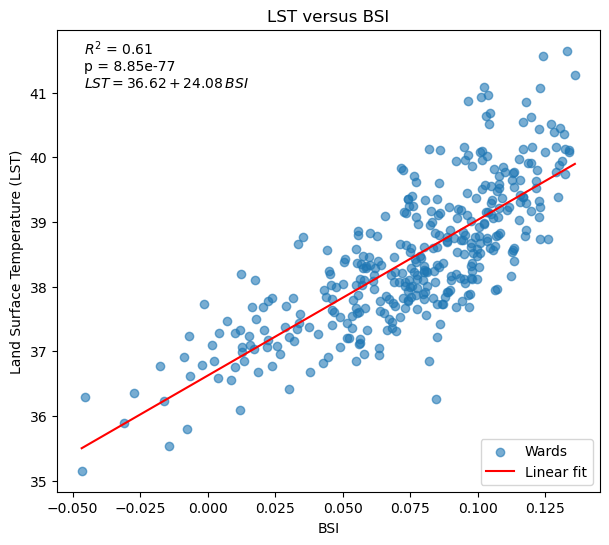

In [77]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("BSI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus BSI")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,BSI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [78]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['BSI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     571.0
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           8.85e-77
Time:                        22:26:36   Log-Likelihood:                -384.29
No. Observations:                 369   AIC:                             772.6
Df Residuals:                     367   BIC:                             780.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.6229      0.084    433.717      0.0

In [79]:
pearsonr(merged['BSI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.7802074294529298), pvalue=np.float64(8.853023789998318e-77))